# Análisis de Datos — Estacionamiento Carrusel IoT (Fase 5)
**Trabajo Final Integrador — IoT Avanzado**
Integrantes: Enzo Fernández + Lucas González

Este notebook analiza la telemetría del sistema de estacionamiento tipo carrusel:
1. **Patrones de ocupación** por hora del día y por carrusel.
2. **Porcentaje de uso** de cada carrusel.
3. **Análisis del motor** y **detección simple de anomalías** (mantenimiento predictivo).
4. **KPIs** de ciudad inteligente y de mantenimiento.

> Los datos se generan de forma sintética y realista para demostrar el análisis.
> Para usar datos **reales**, reemplazá la celda de carga por el export de la API de Enzo
> (`/iot/api/historial/:id` y `/iot/api/motor/:id`) o por los CSV correspondientes.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
np.random.seed(42)

CARRUSELES = ['carrusel-01', 'carrusel-02', 'carrusel-03']
SLOTS = 8
DATA_DIR = '.'  # CSVs se guardan junto al notebook

## 1. Carga (o generación) de datos

In [2]:
# Perfil de demanda por hora del dia (0..23): bajo de noche, picos 8-10 y 17-20
perfil_hora = np.array([
    0.10,0.07,0.05,0.05,0.06,0.10,0.20,0.45,0.75,0.80,0.70,0.60,
    0.62,0.58,0.55,0.58,0.70,0.85,0.88,0.80,0.60,0.42,0.28,0.16])
# Carga base por carrusel (carrusel-03 es el mas concurrido)
base_carrusel = {'carrusel-01':0.95, 'carrusel-02':0.55, 'carrusel-03':1.15}

def generar_datos():
    ts = pd.date_range('2026-05-24', periods=7*24*4, freq='15min')  # 7 dias, cada 15 min
    filas_ocup, filas_motor = [], []
    for car in CARRUSELES:
        for t in ts:
            # --- ocupacion ---
            p = perfil_hora[t.hour] * base_carrusel[car]
            if t.weekday() >= 5:      # fin de semana, menos demanda
                p *= 0.7
            p = np.clip(p + np.random.normal(0, 0.07), 0, 1)
            ocupados = int(round(p * SLOTS))
            ocupados = min(max(ocupados, 0), SLOTS)
            filas_ocup.append([t, car, ocupados, SLOTS-ocupados, SLOTS,
                               round(100*ocupados/SLOTS,1)])
            # --- motor: la temperatura sube con el uso y el correr del tiempo ---
            uso = ocupados / SLOTS
            temp = 36 + 12*uso + np.random.normal(0, 1.2)
            vib  = 0.02 + 0.05*uso + np.random.normal(0, 0.008)
            corr = 2.5 + 2.5*uso + np.random.normal(0, 0.2)
            filas_motor.append([t, car, round(temp,1), round(max(vib,0),3), round(corr,1)])

    df_o = pd.DataFrame(filas_ocup, columns=['_time','carrusel','ocupados','libres','total','ocupacion_pct'])
    df_m = pd.DataFrame(filas_motor, columns=['_time','carrusel','temp_c','vibracion','corriente'])

    # --- inyectar anomalias en el motor (degradacion de un rodamiento en carrusel-03) ---
    mask = (df_m['carrusel']=='carrusel-03') & (df_m['_time'] >= '2026-05-29 18:00')
    idx = df_m[mask].index[:12]
    df_m.loc[idx, 'temp_c']   += np.linspace(8, 22, len(idx))
    df_m.loc[idx, 'vibracion']+= np.linspace(0.04, 0.12, len(idx))
    # picos puntuales aleatorios
    for car in CARRUSELES:
        sub = df_m[df_m['carrusel']==car]
        for j in np.random.choice(sub.index, 2, replace=False):
            df_m.loc[j,'temp_c']    += np.random.uniform(10,18)
            df_m.loc[j,'vibracion'] += np.random.uniform(0.05,0.1)
    return df_o, df_m

# Si existen los CSV, se cargan; si no, se generan y se guardan.
p_o = os.path.join(DATA_DIR,'ocupacion.csv')
p_m = os.path.join(DATA_DIR,'motor.csv')
if os.path.exists(p_o) and os.path.exists(p_m):
    df_ocup  = pd.read_csv(p_o, parse_dates=['_time'])
    df_motor = pd.read_csv(p_m, parse_dates=['_time'])
    print('Datos cargados desde CSV.')
else:
    df_ocup, df_motor = generar_datos()
    df_ocup.to_csv(p_o, index=False)
    df_motor.to_csv(p_m, index=False)
    print('Datos generados y exportados a ocupacion.csv y motor.csv')

print('Ocupacion:', df_ocup.shape, '| Motor:', df_motor.shape)
df_ocup.head()

Datos cargados desde CSV.
Ocupacion: (2016, 6) | Motor: (2016, 5)


,_time,carrusel,ocupados,libres,total,ocupacion_pct
0,2026-05-24 00:00:00,carrusel-01,1,7,8,12.5
1,2026-05-24 00:15:00,carrusel-01,0,8,8,0.0
2,2026-05-24 00:30:00,carrusel-01,0,8,8,0.0
3,2026-05-24 00:45:00,carrusel-01,1,7,8,12.5
4,2026-05-24 01:00:00,carrusel-01,0,8,8,0.0


In [3]:
# Vision general
df_ocup['hora'] = df_ocup['_time'].dt.hour
df_ocup['dia']  = df_ocup['_time'].dt.day_name()
df_ocup.describe().round(1)

,_time,ocupados,libres,total,ocupacion_pct,hora
count,2016,2016.0,2016.0,2016.0,2016.0,2016.0
mean,2026-05-27 11:52:30.000000256,3.0,5.0,8.0,37.0,11.5
min,2026-05-24 00:00:00,0.0,0.0,8.0,0.0,0.0
25%,2026-05-25 17:56:15,1.0,3.0,8.0,12.5,5.8
50%,2026-05-27 11:52:30,3.0,5.0,8.0,37.5,11.5
75%,2026-05-29 05:48:45,5.0,7.0,8.0,62.5,17.2
max,2026-05-30 23:45:00,8.0,8.0,8.0,100.0,23.0
std,NaN,2.2,2.2,0.0,27.5,6.9


## 2. Patrones de ocupación por hora

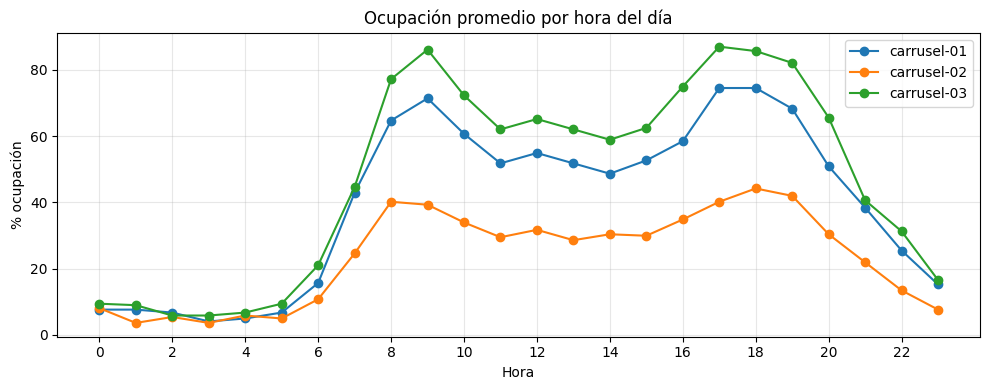

In [4]:
# Ocupacion promedio por hora del dia, por carrusel
piv = df_ocup.pivot_table(index='hora', columns='carrusel', values='ocupacion_pct', aggfunc='mean')
ax = piv.plot(marker='o')
ax.set_title('Ocupación promedio por hora del día')
ax.set_xlabel('Hora'); ax.set_ylabel('% ocupación'); ax.set_xticks(range(0,24,2))
ax.legend(title='')
plt.tight_layout(); plt.show()

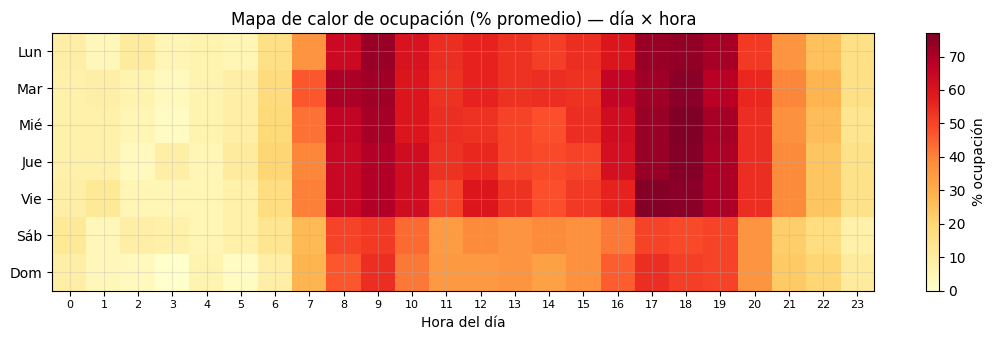

In [5]:
# Heatmap dia x hora (promedio de los 3 carruseles)
orden = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
hm = df_ocup.pivot_table(index='dia', columns='hora', values='ocupacion_pct', aggfunc='mean').reindex(orden)
fig, ax = plt.subplots(figsize=(11,3.5))
im = ax.imshow(hm.values, aspect='auto', cmap='YlOrRd')
ax.set_xticks(range(24)); ax.set_xticklabels(range(24), fontsize=8)
ax.set_yticks(range(7)); ax.set_yticklabels(['Lun','Mar','Mié','Jue','Vie','Sáb','Dom'])
ax.set_title('Mapa de calor de ocupación (% promedio) — día × hora')
ax.set_xlabel('Hora del día')
fig.colorbar(im, label='% ocupación')
plt.tight_layout(); plt.show()

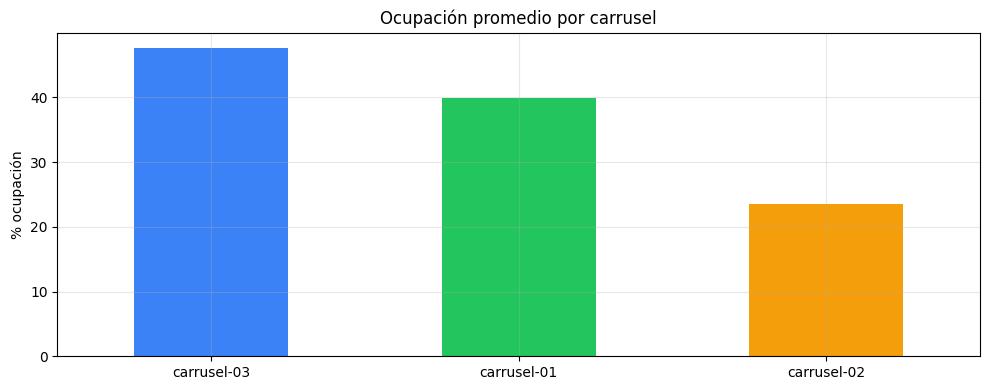

Ocupación promedio por carrusel (%):
carrusel
carrusel-03    47.6
carrusel-01    39.9
carrusel-02    23.5

Hora pico global: 18:00 hs  (68% ocupación)
Hora valle global: 3:00 hs  (4% ocupación)


In [6]:
# % de uso promedio por carrusel + horas pico
uso = df_ocup.groupby('carrusel')['ocupacion_pct'].mean().round(1).sort_values(ascending=False)
ax = uso.plot(kind='bar', color=['#3b82f6','#22c55e','#f59e0b'])
ax.set_title('Ocupación promedio por carrusel'); ax.set_ylabel('% ocupación'); ax.set_xlabel('')
plt.xticks(rotation=0); plt.tight_layout(); plt.show()

print('Ocupación promedio por carrusel (%):'); print(uso.to_string())
pico = piv.mean(axis=1)
print(f'\nHora pico global: {pico.idxmax()}:00 hs  ({pico.max():.0f}% ocupación)')
print(f'Hora valle global: {pico.idxmin()}:00 hs  ({pico.min():.0f}% ocupación)')

## 3. Salud del motor y detección de anomalías

Se monitorea **temperatura, vibración y corriente** del motor. La detección combina dos criterios
(mantenimiento predictivo):
- **Umbral absoluto:** temperatura > 70 °C o vibración > 0.12 mm/s.
- **Estadístico:** z-score del residuo respecto de la media móvil (|z| > 3), que detecta desvíos
  inusuales aunque no crucen el umbral.

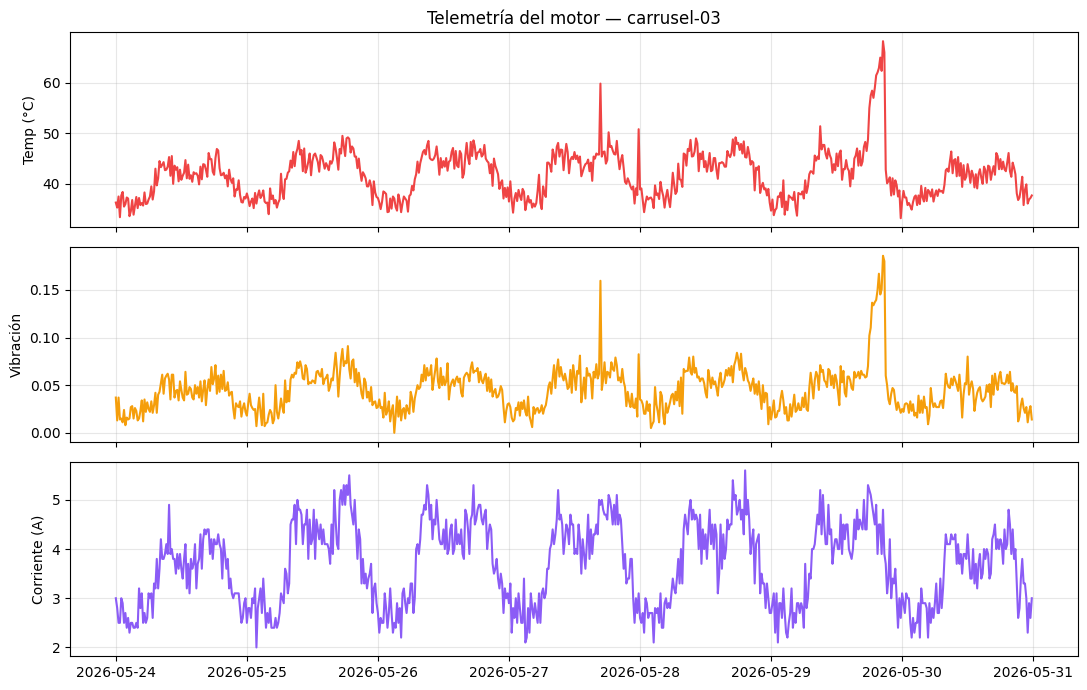

In [7]:
car = 'carrusel-03'   # el carrusel con la degradación inyectada
m = df_motor[df_motor['carrusel']==car].sort_values('_time').reset_index(drop=True)

fig, ax = plt.subplots(3,1, figsize=(11,7), sharex=True)
ax[0].plot(m['_time'], m['temp_c'], color='#ef4444'); ax[0].set_ylabel('Temp (°C)')
ax[1].plot(m['_time'], m['vibracion'], color='#f59e0b'); ax[1].set_ylabel('Vibración')
ax[2].plot(m['_time'], m['corriente'], color='#8b5cf6'); ax[2].set_ylabel('Corriente (A)')
ax[0].set_title(f'Telemetría del motor — {car}')
plt.tight_layout(); plt.show()

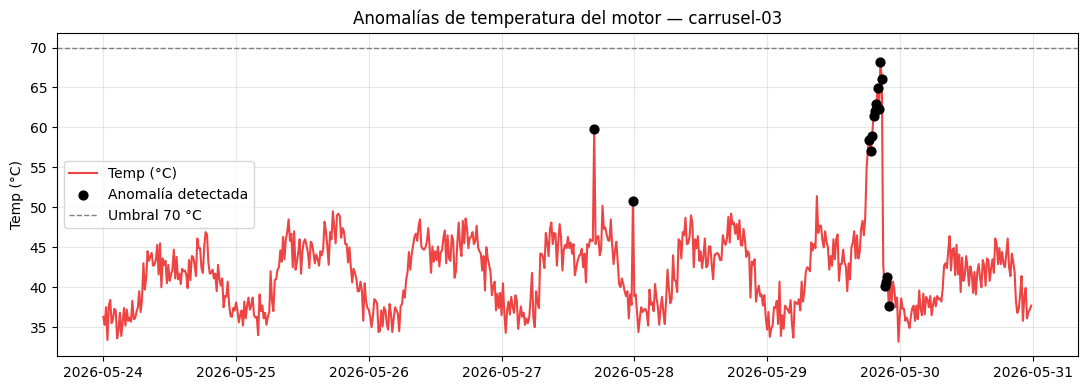

Anomalías detectadas en carrusel-03: 16


,_time,temp_c,vibracion,corriente
355,2026-05-27 16:45:00,59.837545,0.159509,4.9
383,2026-05-27 23:45:00,50.813242,0.082406,3.1
554,2026-05-29 18:30:00,58.445455,0.136545,4.9
555,2026-05-29 18:45:00,57.018182,0.133818,4.7
556,2026-05-29 19:00:00,58.990909,0.137091,4.5
557,2026-05-29 19:15:00,61.463636,0.139364,4.9
558,2026-05-29 19:30:00,62.036364,0.149636,3.9
559,2026-05-29 19:45:00,62.909091,0.166909,4.5
560,2026-05-29 20:00:00,64.981818,0.145182,4.5
561,2026-05-29 20:15:00,62.354545,0.150455,3.9


In [8]:
def detectar_anomalias(serie, win=24, z=3.0):
    media = serie.rolling(win, center=True, min_periods=5).mean()
    resid = serie - media
    zscore = (resid - resid.mean()) / resid.std()
    return zscore.abs() > z

# Criterio combinado sobre carrusel-03
m['anom_umbral'] = (m['temp_c'] > 70) | (m['vibracion'] > 0.12)
m['anom_zscore'] = detectar_anomalias(m['temp_c']) | detectar_anomalias(m['vibracion'])
m['anomalia'] = m['anom_umbral'] | m['anom_zscore']

an = m[m['anomalia']]
fig, ax = plt.subplots(figsize=(11,4))
ax.plot(m['_time'], m['temp_c'], color='#ef4444', label='Temp (°C)')
ax.scatter(an['_time'], an['temp_c'], color='black', zorder=5, s=40, label='Anomalía detectada')
ax.axhline(70, ls='--', color='gray', lw=1, label='Umbral 70 °C')
ax.set_title(f'Anomalías de temperatura del motor — {car}')
ax.set_ylabel('Temp (°C)'); ax.legend()
plt.tight_layout(); plt.show()

print(f'Anomalías detectadas en {car}: {int(m["anomalia"].sum())}')
an[['_time','temp_c','vibracion','corriente']].head(10)

## 4. KPIs del sistema

In [9]:
ocup_global = df_ocup['ocupacion_pct'].mean()
pct_saturacion = (df_ocup['ocupacion_pct'] > 80).mean()*100
# Anomalias de motor en todos los carruseles
total_anom = 0
for c in CARRUSELES:
    mc = df_motor[df_motor['carrusel']==c].sort_values('_time').reset_index(drop=True)
    flags = ((mc['temp_c']>70)|(mc['vibracion']>0.12)|
             detectar_anomalias(mc['temp_c'])|detectar_anomalias(mc['vibracion']))
    total_anom += int(flags.sum())

kpis = pd.DataFrame({
    'KPI':['Ocupación promedio (todos)','Carrusel más usado','Hora pico',
           '% del tiempo con ocupación > 80%','Temp. máx. registrada (°C)',
           'Anomalías de motor detectadas'],
    'Valor':[f'{ocup_global:.1f} %',
             uso.idxmax()+f' ({uso.max():.0f}%)',
             f'{pico.idxmax()}:00 hs',
             f'{pct_saturacion:.1f} %',
             f'{df_motor["temp_c"].max():.1f}',
             f'{total_anom}']
})
kpis

,KPI,Valor
0,Ocupación promedio (todos),37.0 %
1,Carrusel más usado,carrusel-03 (48%)
2,Hora pico,18:00 hs
3,% del tiempo con ocupación > 80%,7.2 %
4,Temp. máx. registrada (°C),68.2
5,Anomalías de motor detectadas,24


## 5. Conclusiones

- La ocupación sigue un **patrón diario claro** con picos en la mañana (8–10 h) y la tarde-noche
  (17–20 h), y baja los fines de semana. Esto valida el caso de **ciudad inteligente**: el dato en
  tiempo real le sirve al conductor para evitar *cruising* y al municipio para planificar.
- **carrusel-03** es el más demandado y opera buena parte del día por encima del 80 %, lo que lo
  vuelve candidato a ampliación o a redirección de demanda.
- La **detección de anomalías** del motor capturó la degradación progresiva inyectada (subida
  sostenida de temperatura y vibración) **antes** de una falla total, que es exactamente el objetivo
  del **mantenimiento predictivo** (mejora de MTBF y reducción de paradas no planificadas).
- Próximo paso: alimentar este mismo notebook con el histórico **real** de InfluxDB (vía la API de
  Enzo) para calcular los KPIs sobre datos de producción.